# 04b_ModelComparison_RF_XGB

폴더명에서 **TS**, **WFR** 추출 → 시계열 통계값 피처에 추가.  
RF / XGB는 시퀀스를 직접 처리하지 못하므로 각 윈도우(30×2)에서 통계값을 추출해 flat 피처 벡터로 변환.

| 피처 그룹 | 내용 |
|---|---|
| V 통계 | mean, std, min, max, range, median, skew, kurt (8개) |
| I 통계 | mean, std, min, max, range, median, skew, kurt (8개) |
| TS, WFR | 윈도우 내 상수값 (2개) |
| **합계** | **18개 피처** |

**모델 비교**: RandomForest vs XGBoost (3-Fold Stratified CV 랜덤 탐색)

In [1]:
from pathlib import Path

BASE_DIR  = Path.home() / 'Desktop' / 'ai1' / 'original_INC_202501'
MODEL_DIR = Path.home() / 'Desktop' / 'ai1' / 'rf_xgb_model'
MODEL_DIR.mkdir(exist_ok=True)

SENSOR_INTERVAL = 0.1
WINDOW_DURATION = 3.0
STEP_DURATION   = 1.0
WINDOW_SIZE = int(WINDOW_DURATION / SENSOR_INTERVAL)   # 30
STEP_SIZE   = int(STEP_DURATION   / SENSOR_INTERVAL)   # 10
FEATURES    = ['Avg Voltage', 'Avg Current']

NORMAL_TEST_IDS   = {1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 28, 29, 30, 44}
ABNORMAL_TEST_IDS = {6, 31, 45} | set(range(32, 44))
NORMAL_VAL_IDS    = set(range(3, 10))
ABNORMAL_VAL_IDS  = {1, 2}
VAL_TRIAL_IDS     = {44, 45}

N_ITER      = 20
RANDOM_SEED = 42

print(f'WINDOW_SIZE: {WINDOW_SIZE},  STEP_SIZE: {STEP_SIZE}')

WINDOW_SIZE: 30,  STEP_SIZE: 10


In [2]:
import re, pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import itertools
import warnings
warnings.filterwarnings('ignore')

from scipy.stats import skew, kurtosis

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, roc_auc_score, roc_curve,
                              average_precision_score, precision_recall_curve,
                              confusion_matrix, f1_score, precision_score, recall_score)

import xgboost as xgb

np.random.seed(RANDOM_SEED)
cv3 = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

print('xgboost :', xgb.__version__)

xgboost : 3.2.0


In [3]:
# =========================
# 데이터 로드 (04와 동일)
# V, I: trial z-score / TS, WFR: raw
# =========================

def parse_folder_id(name):
    m = re.match(r'^(Test|Val)(\d+)_', name, flags=re.IGNORECASE)
    if not m: return None, None
    return m.group(1).capitalize(), int(m.group(2))

def parse_meta(name):
    m = re.search(r'_(\d+)TS_(\d+)WFR', name, re.IGNORECASE)
    if not m: return None, None
    return float(m.group(1)), float(m.group(2))

def get_label(prefix, idx):
    if prefix == 'Test':
        if idx in NORMAL_TEST_IDS:   return 0
        if idx in ABNORMAL_TEST_IDS: return 1
    elif prefix == 'Val':
        if idx in NORMAL_VAL_IDS:    return 0
        if idx in ABNORMAL_VAL_IDS:  return 1
    raise ValueError()

def get_split(prefix, idx):
    if prefix == 'Val':          return 'test'
    if prefix == 'Test':
        if idx in VAL_TRIAL_IDS: return 'val'
        return 'train'
    raise ValueError()

records = []
for d in sorted(BASE_DIR.iterdir()):
    if not d.is_dir(): continue
    prefix, idx = parse_folder_id(d.name)
    if prefix is None: continue
    ts, wfr = parse_meta(d.name)
    if ts is None:
        print(f'[SKIP] TS/WFR 파싱 실패: {d.name}'); continue
    try:
        label = get_label(prefix, idx)
        split = get_split(prefix, idx)
    except ValueError:
        continue
    csvs = list(d.glob('*.csv'))
    if not csvs: continue

    vi = pd.read_csv(csvs[0])[FEATURES].astype(float).values
    mean, std = vi.mean(0), vi.std(0)
    std[std < 1e-8] = 1e-8
    vi_norm = (vi - mean) / std

    n = len(vi_norm)
    data = np.hstack([vi_norm,
                      np.full((n, 1), ts),
                      np.full((n, 1), wfr)]).astype(np.float32)

    records.append({'folder': d.name, 'label': label, 'split': split,
                    'data': data, 'ts': ts, 'wfr': wfr})
    print(f'{d.name:45s}  {split:5s}  label={label}  TS={int(ts):2d}  WFR={int(wfr):3d}')

summary = pd.DataFrame([{k: r[k] for k in ('folder','split','label','ts','wfr')} for r in records])
print('\n=== Split 요약 ===')
print(summary.groupby(['split','label']).size().rename('n_trials'))

Test1_160A_20TS_160WFR                         train  label=0  TS=20  WFR=160
Test2_160A_20TS_190WFR                         train  label=0  TS=20  WFR=190
Test31_120A_20TS_160WFR                        train  label=1  TS=20  WFR=160
Test32_120A_20TS_190WFR                        train  label=1  TS=20  WFR=190
Test34_120A_30TS_190WFR                        train  label=1  TS=30  WFR=190
Test38_140A_30TS_180WFR                        train  label=1  TS=30  WFR=180
Test3_160A_30TS_160WFR                         train  label=0  TS=30  WFR=160
Test41_140A_25TS_180WFR                        train  label=1  TS=25  WFR=180
Test43_150A_30TS_190WFR                        train  label=1  TS=30  WFR=190
Test44_150A_25TS_160WFR                        val    label=0  TS=25  WFR=160
Test45_150A_25TS_180WFR                        val    label=1  TS=25  WFR=180
Test5_160A_40TS_160WFR                         train  label=0  TS=40  WFR=160
Test7_180A_20TS_160WFR                         train  label=0  T

In [4]:
def make_windows(data, ws, ss):
    return np.stack([data[s:s+ws] for s in range(0, len(data)-ws+1, ss)])

buckets = {'train': ([], []), 'val': ([], []), 'test': ([], [])}
for r in records:
    wins   = make_windows(r['data'], WINDOW_SIZE, STEP_SIZE)
    labels = np.full(len(wins), r['label'], dtype=np.float32)
    buckets[r['split']][0].append(wins)
    buckets[r['split']][1].append(labels)

X_win = {s: np.vstack(buckets[s][0]).astype(np.float32) for s in buckets}
y     = {s: np.concatenate(buckets[s][1]).astype(int) for s in buckets}

n_feat = X_win['train'].shape[2]   # 4

for s in ('train', 'val', 'test'):
    u, c = np.unique(y[s], return_counts=True)
    cnt  = dict(zip(u, c))
    print(f'{s:5s}  windows={X_win[s].shape}  normal={cnt.get(0,0):4d}  abnormal={cnt.get(1,0):4d}')

train  windows=(364, 30, 4)  normal= 183  abnormal= 181
val    windows=(58, 30, 4)  normal=  29  abnormal=  29
test   windows=(150, 30, 4)  normal=  95  abnormal=  55


In [5]:
# 글로벌 StandardScaler (4 채널)
scaler_win = StandardScaler()
scaler_win.fit(X_win['train'].reshape(-1, n_feat))

def scale_win(arr):
    n, w, f = arr.shape
    return scaler_win.transform(arr.reshape(-1, f)).reshape(n, w, f).astype(np.float32)

Xs_win = {s: scale_win(X_win[s]) for s in X_win}

FEAT_NAMES = ['V', 'I', 'TS', 'WFR']
print('=== 글로벌 스케일러 (train 기준) ===')
for i, name in enumerate(FEAT_NAMES):
    print(f'  {name:5s}  mean={scaler_win.mean_[i]:+8.4f}  std={scaler_win.scale_[i]:.4f}')

=== 글로벌 스케일러 (train 기준) ===
  V      mean= +0.0204  std=0.6635
  I      mean= +0.0815  std=0.2982
  TS     mean=+24.0659  std=5.6043
  WFR    mean=+176.0989  std=13.8933


In [6]:
# =========================
# 시계열 통계값 추출 (윈도우 → flat 피처 벡터)
# V, I: 8개 통계 / TS, WFR: 상수값 1개씩
# =========================

STAT_FEAT_NAMES = (
    [f'V_{s}' for s in ['mean','std','min','max','range','median','skew','kurt']] +
    [f'I_{s}' for s in ['mean','std','min','max','range','median','skew','kurt']] +
    ['TS', 'WFR']
)  # 18개

def extract_stats(X_windows):
    """(N, 30, 4) → (N, 18) 통계 피처 행렬"""
    rows = []
    for win in X_windows:          # win: (30, 4)
        row = []
        for ch in [0, 1]:          # V, I
            s = win[:, ch]
            row.extend([
                s.mean(), s.std(), s.min(), s.max(),
                s.max() - s.min(),
                float(np.median(s)),
                float(skew(s)),
                float(kurtosis(s)),
            ])
        row.append(float(win[0, 2]))   # TS  (상수)
        row.append(float(win[0, 3]))   # WFR (상수)
        rows.append(row)
    return np.array(rows, dtype=np.float32)

Xf = {s: extract_stats(Xs_win[s]) for s in Xs_win}

print(f'피처 수: {len(STAT_FEAT_NAMES)}  {STAT_FEAT_NAMES}')
for s in ('train', 'val', 'test'):
    print(f'{s:5s}  {Xf[s].shape}')

피처 수: 18  ['V_mean', 'V_std', 'V_min', 'V_max', 'V_range', 'V_median', 'V_skew', 'V_kurt', 'I_mean', 'I_std', 'I_min', 'I_max', 'I_range', 'I_median', 'I_skew', 'I_kurt', 'TS', 'WFR']
train  (364, 18)
val    (58, 18)
test   (150, 18)


In [7]:
# CV용 train+val 합산
Xf_tv = np.vstack([Xf['train'], Xf['val']])
yf_tv = np.concatenate([y['train'], y['val']])

print(f'Xf_tv : {Xf_tv.shape}  (0={int((yf_tv==0).sum())}, 1={int((yf_tv==1).sum())})')
print(f'Xf_test: {Xf["test"].shape}')

Xf_tv : (422, 18)  (0=212, 1=210)
Xf_test: (150, 18)


In [8]:
# =========================
# 공통 평가 함수 (sklearn 모델용)
# =========================

roc_data = {}
results  = {}

def evaluate(model_name, model_obj, X_test, y_test):
    y_prob = model_obj.predict_proba(X_test)[:, 1]
    y_true = y_test.astype(int)
    y_pred = (y_prob >= 0.5).astype(int)

    roc_auc = roc_auc_score(y_true, y_prob)
    pr_auc  = average_precision_score(y_true, y_prob)

    print(f'\n===== {model_name} (threshold=0.5) =====')
    print(classification_report(y_true, y_pred,
                                target_names=['Normal(0)', 'Abnormal(1)'],
                                zero_division=0))
    print(f'ROC-AUC : {roc_auc:.4f}  |  PR-AUC : {pr_auc:.4f}')

    roc_data[model_name] = (y_true, y_prob)
    results[model_name]  = {
        'precision': precision_score(y_true, y_pred, zero_division=0),
        'recall':    recall_score(y_true, y_pred, zero_division=0),
        'f1':        f1_score(y_true, y_pred, zero_division=0),
        'roc_auc':   roc_auc,
        'pr_auc':    pr_auc,
    }

print('평가 함수 준비 완료')

평가 함수 준비 완료


In [9]:
# =========================
# RandomForest — 3-Fold CV 랜덤 탐색
# =========================

rf_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf':  [1, 2, 4],
    'max_features':      ['sqrt', 'log2'],
}

rf_search = RandomizedSearchCV(
    estimator  = RandomForestClassifier(random_state=RANDOM_SEED, n_jobs=-1),
    param_distributions = rf_param_dist,
    n_iter     = N_ITER,
    cv         = cv3,
    scoring    = 'roc_auc',
    refit      = True,
    random_state = RANDOM_SEED,
    n_jobs     = -1,
    verbose    = 1,
)

print('RandomForest CV 탐색 시작...')
rf_search.fit(Xf_tv, yf_tv)

print(f'\n최적 파라미터 : {rf_search.best_params_}')
print(f'CV best AUC   : {rf_search.best_score_:.4f}')

rf_model = rf_search.best_estimator_
with open(MODEL_DIR / 'rf_model.pkl', 'wb') as f:
    pickle.dump(rf_model, f)
print('모델 저장 완료')

RandomForest CV 탐색 시작...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

최적 파라미터 : {'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 20}
CV best AUC   : 0.9975
모델 저장 완료


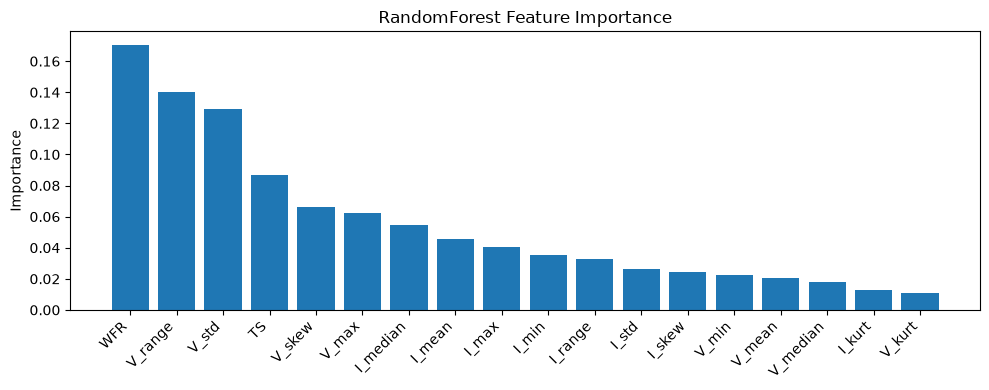


===== RF (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.62      0.67      0.64        95
 Abnormal(1)       0.33      0.27      0.30        55

    accuracy                           0.53       150
   macro avg       0.47      0.47      0.47       150
weighted avg       0.51      0.53      0.52       150

ROC-AUC : 0.6006  |  PR-AUC : 0.4117


In [10]:
# RF 피처 중요도
importances = rf_model.feature_importances_
sorted_idx  = np.argsort(importances)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(importances)), importances[sorted_idx])
ax.set_xticks(range(len(importances)))
ax.set_xticklabels([STAT_FEAT_NAMES[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_title('RandomForest Feature Importance')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'rf_importance.png'), dpi=150)
plt.show()

# RF 평가
evaluate('RF', rf_model, Xf['test'], y['test'])

In [11]:
# =========================
# XGBoost — 3-Fold CV 랜덤 탐색
# =========================

xgb_param_dist = {
    'n_estimators':      [100, 200, 300],
    'max_depth':         [3, 5, 7],
    'learning_rate':     [0.01, 0.05, 0.1, 0.2],
    'subsample':         [0.6, 0.8, 1.0],
    'colsample_bytree':  [0.6, 0.8, 1.0],
    'min_child_weight':  [1, 3, 5],
    'gamma':             [0, 0.1, 0.5],
}

xgb_search = RandomizedSearchCV(
    estimator  = xgb.XGBClassifier(
        objective    = 'binary:logistic',
        eval_metric  = 'auc',
        use_label_encoder = False,
        random_state = RANDOM_SEED,
        n_jobs       = -1,
        verbosity    = 0,
    ),
    param_distributions = xgb_param_dist,
    n_iter     = N_ITER,
    cv         = cv3,
    scoring    = 'roc_auc',
    refit      = True,
    random_state = RANDOM_SEED,
    n_jobs     = -1,
    verbose    = 1,
)

print('XGBoost CV 탐색 시작...')
xgb_search.fit(Xf_tv, yf_tv)

print(f'\n최적 파라미터 : {xgb_search.best_params_}')
print(f'CV best AUC   : {xgb_search.best_score_:.4f}')

xgb_model = xgb_search.best_estimator_
xgb_model.save_model(str(MODEL_DIR / 'xgb_model.json'))
print('모델 저장 완료')

XGBoost CV 탐색 시작...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

최적 파라미터 : {'subsample': 0.6, 'n_estimators': 100, 'min_child_weight': 1, 'max_depth': 3, 'learning_rate': 0.2, 'gamma': 0, 'colsample_bytree': 0.8}
CV best AUC   : 0.9986
모델 저장 완료


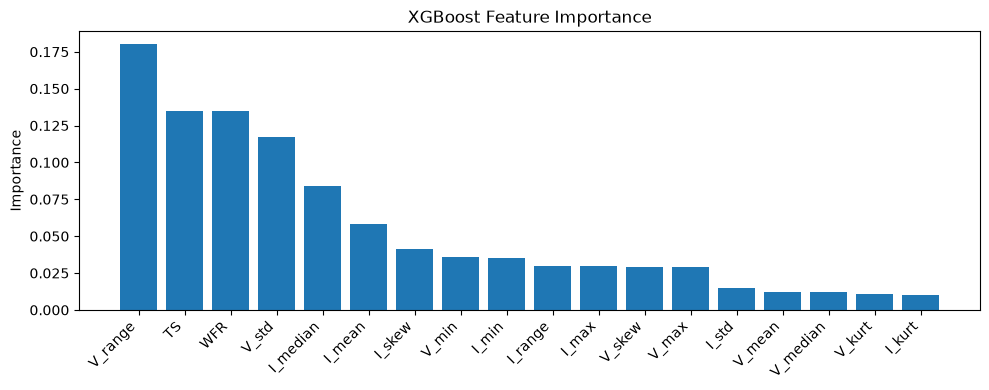


===== XGB (threshold=0.5) =====
              precision    recall  f1-score   support

   Normal(0)       0.64      0.94      0.76        95
 Abnormal(1)       0.50      0.11      0.18        55

    accuracy                           0.63       150
   macro avg       0.57      0.52      0.47       150
weighted avg       0.59      0.63      0.55       150

ROC-AUC : 0.6264  |  PR-AUC : 0.5031


In [12]:
# XGB 피처 중요도
xgb_imp = xgb_model.feature_importances_
sorted_idx = np.argsort(xgb_imp)[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(range(len(xgb_imp)), xgb_imp[sorted_idx])
ax.set_xticks(range(len(xgb_imp)))
ax.set_xticklabels([STAT_FEAT_NAMES[i] for i in sorted_idx], rotation=45, ha='right')
ax.set_title('XGBoost Feature Importance')
ax.set_ylabel('Importance')
plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'xgb_importance.png'), dpi=150)
plt.show()

# XGB 평가
evaluate('XGB', xgb_model, Xf['test'], y['test'])

=== Window-level 비교 (18개 통계 피처 | threshold=0.5) ===
Model  Precision  Recall    F1  ROC-AUC  PR-AUC
   RF      0.326   0.273 0.297    0.601   0.412
  XGB      0.500   0.109 0.179    0.626   0.503


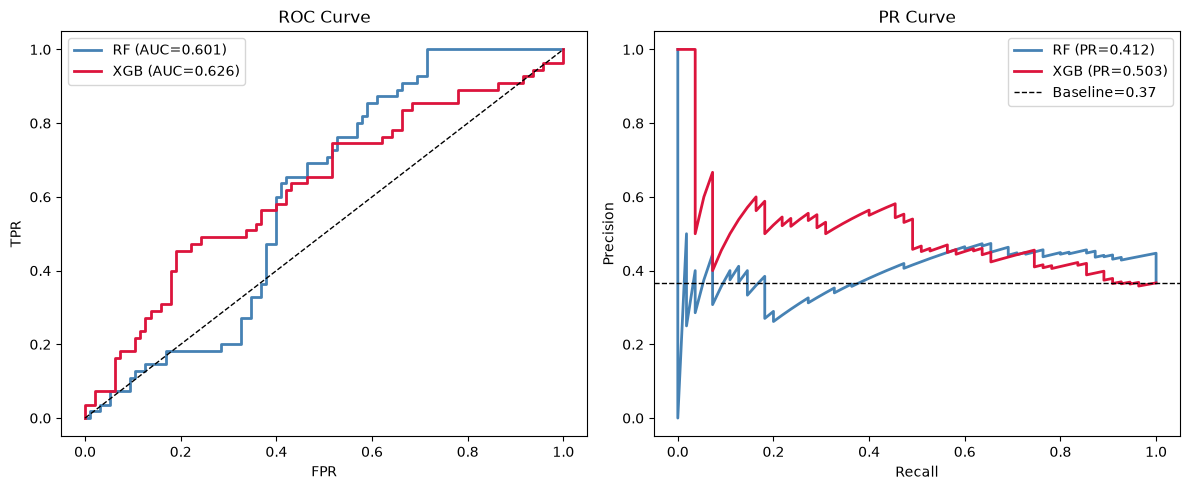

In [13]:
# =========================
# 비교 요약 + ROC/PR 곡선
# =========================

df = pd.DataFrame([
    {'Model': name,
     'Precision': round(v['precision'], 3),
     'Recall':    round(v['recall'], 3),
     'F1':        round(v['f1'], 3),
     'ROC-AUC':   round(v['roc_auc'], 3),
     'PR-AUC':    round(v['pr_auc'], 3)}
    for name, v in results.items()
])
print('=== Window-level 비교 (18개 통계 피처 | threshold=0.5) ===')
print(df.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
colors = ['steelblue', 'crimson']

for (name, (yt, yp)), c in zip(roc_data.items(), colors):
    fpr, tpr, _ = roc_curve(yt, yp)
    axes[0].plot(fpr, tpr, lw=2, color=c,
                  label=f'{name} (AUC={roc_auc_score(yt,yp):.3f})')
    pre, rec, _ = precision_recall_curve(yt, yp)
    axes[1].plot(rec, pre, lw=2, color=c,
                  label=f'{name} (PR={average_precision_score(yt,yp):.3f})')

axes[0].plot([0,1],[0,1],'k--',lw=1)
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR')
axes[0].set_title('ROC Curve'); axes[0].legend()

baseline = list(roc_data.values())[0][0].mean()
axes[1].axhline(baseline, color='k', linestyle='--', lw=1, label=f'Baseline={baseline:.2f}')
axes[1].set_xlabel('Recall'); axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curve'); axes[1].legend()

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'comparison.png'), dpi=150)
plt.show()

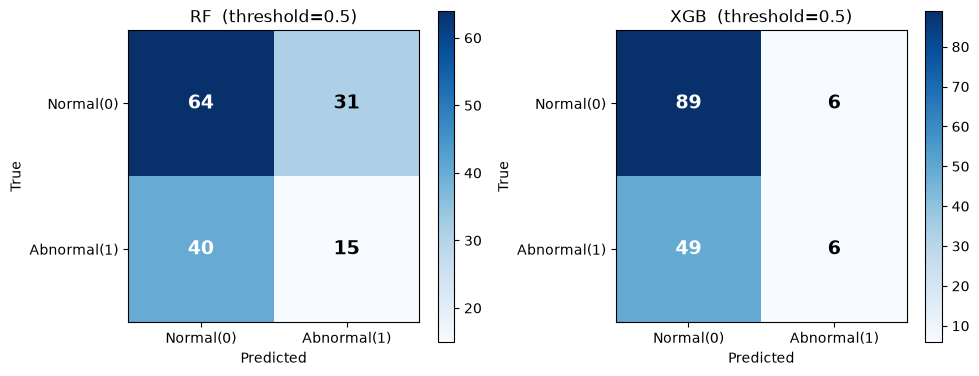

In [14]:
# =========================
# 혼동행렬 (RF vs XGB 나란히)
# =========================

def plot_cm(ax, y_true, y_prob, title):
    y_pred = (y_prob >= 0.5).astype(int)
    cm = confusion_matrix(y_true, y_pred)
    im = ax.imshow(cm, interpolation='nearest', cmap='Blues')
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=[0,1], yticks=[0,1],
           xticklabels=['Normal(0)','Abnormal(1)'],
           yticklabels=['Normal(0)','Abnormal(1)'],
           xlabel='Predicted', ylabel='True', title=title)
    thresh = cm.max() / 2
    for i, j in itertools.product(range(2), range(2)):
        ax.text(j, i, f'{cm[i,j]}',
                ha='center', va='center',
                color='white' if cm[i,j] > thresh else 'black',
                fontsize=14, fontweight='bold')

fig, axes = plt.subplots(1, len(roc_data), figsize=(5 * len(roc_data), 4))
if len(roc_data) == 1:
    axes = [axes]

for ax, (name, (y_true, y_prob)) in zip(axes, roc_data.items()):
    plot_cm(ax, y_true, y_prob, f'{name}  (threshold=0.5)')

plt.tight_layout()
plt.savefig(str(MODEL_DIR / 'confusion_matrix.png'), dpi=150)
plt.show()